## Draw the layer level sparsity distribution.

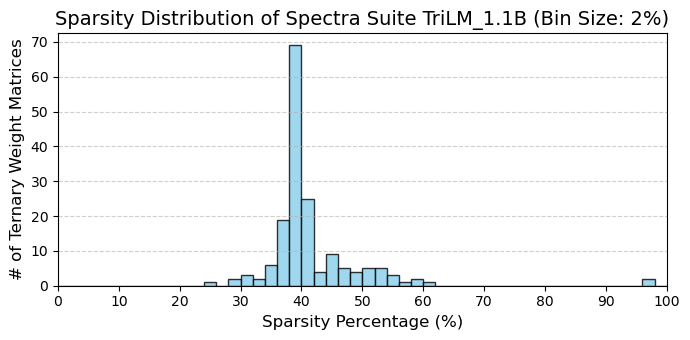

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# BitNet
# data_str = "49.62%	46.47%	42.98%	47.49%	39.13%	38.03%	38.21%	44.21%	41.16%	40.18%	45.26%	60.08%	59.99%	59.93%	41.96%	39.26%	36.30%	42.92%	51.44%	51.49%	51.48%	43.52%	41.76%	37.08%	42.17%	45.31%	45.42%	45.50%	44.85%	42.09%	36.11%	41.34%	42.95%	42.78%	42.99%	46.45%	44.16%	36.19%	41.99%	41.19%	40.97%	41.70%	47.12%	45.89%	37.26%	40.44%	40.79%	40.50%	41.04%	46.88%	45.92%	37.55%	41.50%	41.19%	40.65%	41.15%	50.12%	47.41%	36.71%	42.20%	40.98%	40.33%	40.84%	44.82%	42.46%	36.81%	40.13%	41.03%	40.06%	40.66%	49.11%	47.97%	37.21%	39.84%	40.94%	39.95%	40.27%	48.67%	46.73%	36.70%	39.28%	41.23%	40.09%	40.38%	48.19%	45.92%	36.92%	39.40%	41.53%	40.24%	40.66%	44.63%	42.43%	36.44%	38.87%	41.76%	40.43%	40.78%	50.91%	48.90%	37.56%	41.72%	41.52%	40.30%	40.31%	45.65%	43.48%	36.14%	38.89%	41.45%	40.31%	39.83%	47.69%	45.73%	36.96%	39.53%	41.51%	40.35%	39.97%	49.32%	47.61%	36.67%	38.56%	41.78%	40.66%	39.93%	47.54%	44.46%	36.41%	40.77%	41.86%	40.95%	40.04%	44.62%	42.54%	36.48%	39.22%	41.94%	41.13%	40.25%	49.76%	47.63%	37.89%	40.81%	41.85%	41.16%	40.09%	49.54%	47.26%	38.23%	42.31%	41.29%	40.67%	39.60%	46.78%	43.50%	36.77%	42.19%	40.78%	39.98%	38.96%	49.31%	47.62%	37.71%	41.78%	40.74%	40.07%	38.86%	50.58%	49.60%	39.06%	41.15%	41.02%	40.35%	38.88%	45.29%	44.05%	37.79%	42.07%	40.93%	40.20%	38.72%	45.14%	43.94%	38.56%	42.18%	40.94%	40.20%	38.91%	45.36%	42.82%	36.60%	42.05%	41.33%	40.49%	39.31%	42.86%	40.96%	37.58%	44.44%	41.11%	40.19%	39.46%	42.01%	39.89%	44.37%	54.67%	41.30%	40.38%	40.63%"
# Spectra Suite TriLM_1.1B
data_str = "97.02%	97.22%	24.23%	40.36%	34.39%	31.06%	32.90%	34.37%	36.32%	45.42%	44.76%	35.83%	36.15%	37.40%	35.65%	37.58%	41.83%	40.41%	36.53%	37.03%	40.02%	37.67%	38.99%	40.87%	39.32%	37.07%	37.39%	39.03%	38.80%	40.07%	40.56%	39.32%	37.59%	37.91%	39.17%	41.79%	42.54%	41.92%	40.32%	37.50%	38.03%	39.09%	44.02%	45.42%	39.47%	39.57%	37.81%	38.26%	39.16%	44.40%	46.01%	38.96%	38.90%	38.71%	38.40%	38.86%	43.96%	45.69%	38.93%	39.02%	39.18%	38.96%	39.24%	42.47%	43.96%	38.46%	38.38%	40.05%	39.32%	39.63%	49.01%	51.45%	39.15%	39.51%	39.71%	39.05%	39.32%	48.64%	51.36%	38.51%	39.18%	40.30%	39.19%	39.48%	44.77%	46.35%	39.07%	39.06%	40.44%	39.23%	39.37%	44.15%	45.72%	38.65%	38.80%	40.68%	39.48%	39.61%	50.13%	52.56%	37.67%	39.32%	40.92%	39.49%	39.72%	46.93%	49.15%	37.21%	38.79%	41.14%	39.61%	39.93%	46.14%	47.94%	36.31%	38.33%	41.04%	39.62%	40.02%	52.68%	55.32%	35.42%	39.09%	41.16%	39.32%	39.57%	48.18%	51.27%	34.34%	38.46%	40.59%	39.26%	39.24%	50.64%	53.73%	32.85%	38.56%	40.39%	39.24%	39.27%	54.45%	58.79%	31.30%	38.17%	40.58%	39.00%	38.93%	53.75%	58.06%	30.15%	38.53%	40.41%	38.69%	37.92%	55.58%	60.34%	29.67%	38.17%	40.10%	38.75%	37.79%	52.85%	56.00%	29.90%	41.46%	39.47%	37.97%	39.48%																																										"

# 1. Clean data: Remove '%' and convert to float
data = [float(x.strip('%')) for x in data_str.split()]

# 2. Configuration: Set bin size (e.g., 2% or 5%)
bin_size = 2 
bins = np.arange(0, 101, bin_size) # Creates bins from 0 to 100 with step size

# 3. Create the plot
plt.figure(figsize=(7, 3.5))
plt.hist(data, bins=bins, edgecolor='black', color='skyblue', alpha=0.8)

# 4. Formatting
# plt.title(f'Sparsity Distribution of BitNet b1.58-2B-4T (Bin Size: {bin_size}%)', fontsize=14)
plt.title(f'Sparsity Distribution of Spectra Suite TriLM_1.1B (Bin Size: {bin_size}%)', fontsize=14)
plt.xlabel('Sparsity Percentage (%)', fontsize=12)
plt.ylabel('# of Ternary Weight Matrices', fontsize=12)
plt.xticks(np.arange(0, 101, 10)) # Set ticks every 10%
plt.xlim(0, 100) # Ensure scale is 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
# Save the plot as a PDF  
# plt.savefig("ternaryLLM-BitNet_b1.58-2B-4T.pdf", format="pdf") 
plt.savefig("ternaryLLM-SpectraSuite_1.1B.pdf", format="pdf") 
plt.show()

C:\Users\yiwei\AppData\Local\Temp\ipykernel_25712\2641310395.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['{:.0f}%'.format(x) for x in ax.get_yticks()])


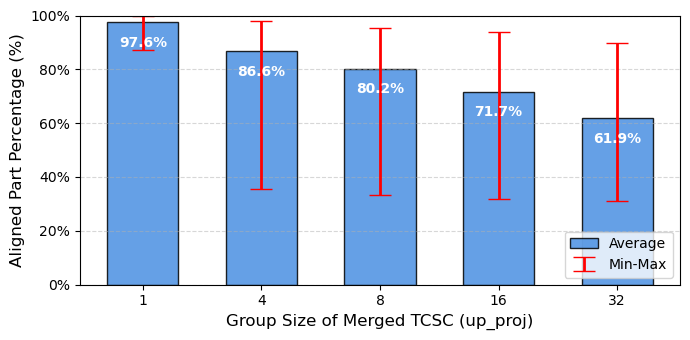

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data from the second table in the image (Decimal format)
groups = ['1','4', '8', '16', '32']

# up proj
max_pct = [1.0000, 0.9792, 0.9553, 0.9369, 0.8966]
min_pct = [0.8722, 0.3557, 0.3331, 0.3188, 0.3095]
avg_pct = [0.9760, 0.8663, 0.8025, 0.7169, 0.6193]
# down proj
# max_pct = [1.0000, 0.9924, 0.9793, 0.9745, 0.9617]
# min_pct = [0.9304, 0.8195, 0.8766, 0.8939, 0.9057]
# avg_pct = [0.9856, 0.9625, 0.9539, 0.9466, 0.9395]

# Convert decimals to actual percentages (0.86 -> 86.63)
avg_vals = [a * 100 for a in avg_pct]
max_vals = [m * 100 for m in max_pct]
min_vals = [mi * 100 for mi in min_pct]

# 2. Calculate the range from the average to the Min and Max
# lower_error: distance from Average down to Min
# upper_error: distance from Average up to Max
lower_error = [avg - mn for avg, mn in zip(avg_vals, min_vals)]
upper_error = [mx - avg for avg, mx in zip(avg_vals, max_vals)]
asymmetric_error = [lower_error, upper_error]

# 3. Create the plot
fig, ax = plt.subplots(figsize=(7, 3.5))

# Primary Bar: Average Values
bars = ax.bar(groups, avg_vals, color='#4a90e2', edgecolor='black', 
              label='Average', alpha=0.85, width=0.6)

# Error Bars: Min and Max Range
ax.errorbar(groups, avg_vals, yerr=asymmetric_error, fmt='none', 
            ecolor='red', capsize=8, elinewidth=2, label='Min-Max')

# 4. Formatting the Y-axis as Percentage
ax.set_ylim(0, 100)  # Standard percentage range
ax.set_ylabel('Aligned Part Percentage (%)', fontsize=12)
ax.set_xlabel('Group Size of Merged TCSC (up_proj)', fontsize=12)
# ax.set_title('Group Performance: Average with Min-Max Range', fontsize=14, fontweight='bold')

# Add percentage symbol to Y-axis tick labels
ax.set_yticklabels(['{:.0f}%'.format(x) for x in ax.get_yticks()])

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='lower right')

# 5. Add text labels for the Average percentages on the bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, -20), # Positioned slightly inside the top of the bar
                textcoords="offset points",
                ha='center', va='bottom', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig("ternaryLLM-up-proj-align-ratio.pdf", format="pdf") 
# plt.savefig("ternaryLLM-down-proj-align-ratio.pdf", format="pdf") 
plt.show()